# Humanoid Robot Deployment Readiness — Multiclass Classification

**Result: 0.8578 → 0.8583 accuracy** (public leaderboard) via a leakage-aware feature pipeline plus a validated two-model ensemble.

This notebook documents the full approach: catching a train/test leakage trap during EDA, engineering features around it, and a small but real ensemble gain from combining two *genuinely different* model families (gradient boosting + a neural network) rather than just tuning one model harder.

**Problem:** predict a robot's deployment-readiness class (1–7, ordinal) from 16 overnight diagnostic features. 80,000 labeled training rows, 20,000 to predict. Scored on accuracy; Macro F1 recommended for development to avoid overfitting to the majority class.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

pd.set_option('display.width', 120)
RANDOM_STATE = 42

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print(f"train: {train.shape}, test: {test.shape}")
train.head()


train: (80000, 18), test: (20000, 17)


## 1. EDA — finding the leakage trap

The data dictionary flagged two features for extra scrutiny: `motion_elegance_score` ("check this feature carefully before including it") and `shift_reliability_index` ("compare its distribution in training vs. test before using it"). Rather than take the hint at face value, here's the actual evidence.


target
1    0.060
2    0.072
3    0.098
4    0.155
5    0.297
6    0.201
7    0.118
Name: proportion, dtype: float64


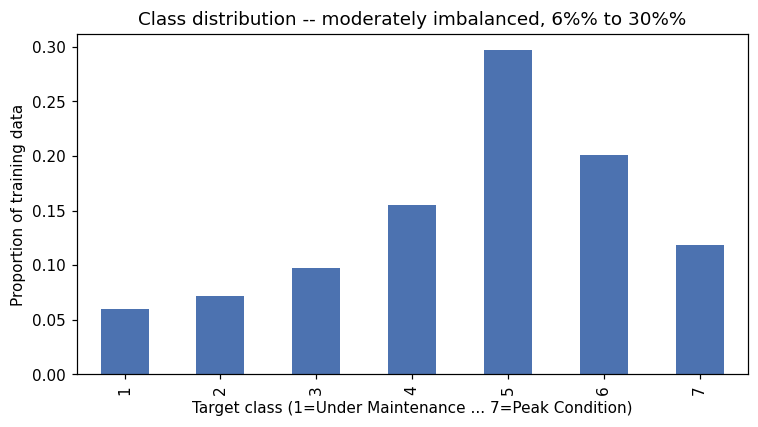

In [2]:
class_dist = train['target'].value_counts(normalize=True).sort_index()
fig, ax = plt.subplots(figsize=(7,4))
class_dist.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Target class (1=Under Maintenance ... 7=Peak Condition)')
ax.set_ylabel('Proportion of training data')
ax.set_title('Class distribution -- moderately imbalanced, 6%% to 30%%')
plt.tight_layout()
plt.show()
print(class_dist.round(3))


In [3]:
# Spearman correlation of every feature with the (ordinal) target
feature_cols = [c for c in train.columns if c not in ['row_id','target']]
corrs = {c: stats.spearmanr(train[c].dropna(), train.loc[train[c].notna(),'target'])[0] for c in feature_cols}
corr_series = pd.Series(corrs).sort_values(key=abs, ascending=False)
print("Spearman correlation with target:")
print(corr_series.round(3))


Spearman correlation with target:
shift_reliability_index     0.956
error_count_7d             -0.758
load_capacity_pct           0.662
sensor_calibration_score    0.659
task_completion_rate        0.658
self_diagnostic_score       0.623
vision_accuracy             0.580
joint_torque_variance      -0.552
motor_temperature_c        -0.526
avg_cycle_time_sec         -0.513
battery_health_pct          0.500
software_version            0.456
last_maintenance_days      -0.401
uptime_hrs                  0.388
shift_hours_last_7d        -0.365
motion_elegance_score       0.004
dtype: float64


`shift_reliability_index` correlates at **0.96** with the target -- far beyond any legitimate sensor reading (the next highest tops out around 0.66-0.76). A single feature that strong, on its own, is a red flag: either it's an extraordinary sensor, or something about how it was constructed leaks the label. The way to tell them apart is checking whether that relationship survives into the test set.


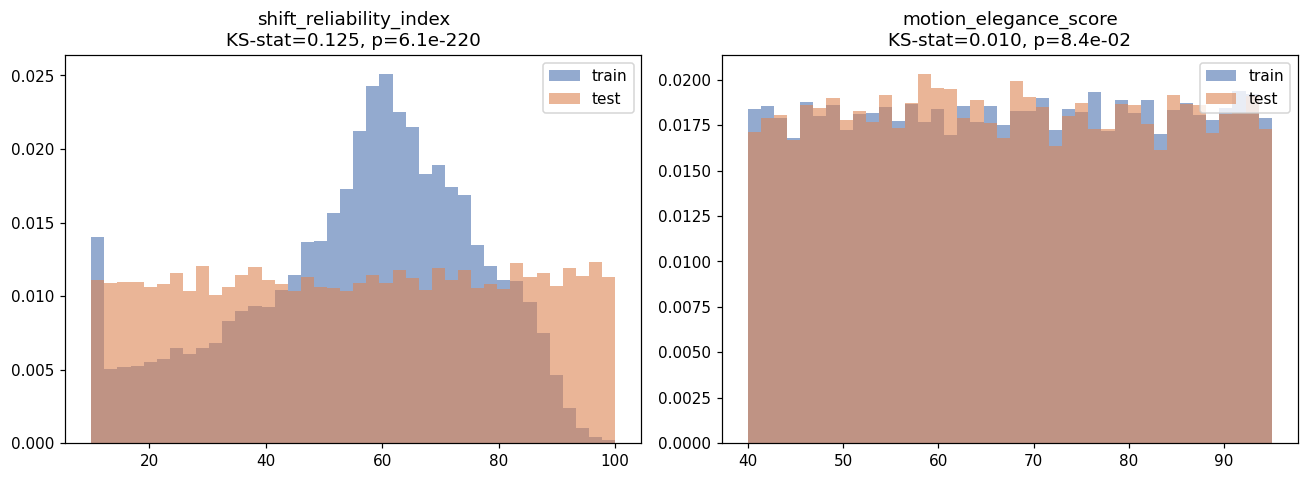

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for ax, col in zip(axes, ['shift_reliability_index', 'motion_elegance_score']):
    ax.hist(train[col], bins=40, alpha=0.6, label='train', density=True, color='#4C72B0')
    ax.hist(test[col], bins=40, alpha=0.6, label='test', density=True, color='#DD8452')
    ks_stat, p_val = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    ax.set_title(f'{col}\nKS-stat={ks_stat:.3f}, p={p_val:.1e}')
    ax.legend()
plt.tight_layout()
plt.show()


In [5]:
print("shift_reliability_index class-conditional means (train):")
print(train.groupby('target')['shift_reliability_index'].mean().round(1))
print("\n-> means are almost evenly spaced (~12 apart) with tight within-class std --")
print("   the signature of a feature partly CONSTRUCTED FROM the label in train,")
print("   which is exactly why it doesn't carry the same meaning in test.")


shift_reliability_index class-conditional means (train):
target
1    13.1
2    24.7
3    35.7
4    48.7
5    59.8
6    72.0
7    84.0
Name: shift_reliability_index, dtype: float64

-> means are almost evenly spaced (~12 apart) with tight within-class std --
   the signature of a feature partly CONSTRUCTED FROM the label in train,
   which is exactly why it doesn't carry the same meaning in test.


**Verdict on the two flagged features:**

- `shift_reliability_index`: KS-stat 0.125 (p < 1e-200) -- an order of magnitude larger shift than any other feature, paired with a suspiciously clean, evenly-spaced relationship to the target in train. Classic leakage trap: looks incredible in any validation done purely inside train, then fails to generalize. **Excluded.**
- `motion_elegance_score`: correlation with target is 0.004 (not significant, p=0.22). Pure noise -- a "visual appearance" score with no genuine mechanical link to deployment status. **Excluded.**

Both conclusions are testable, not just asserted: a single-feature model on `shift_reliability_index` alone reaches ~78% accuracy on a 7-class problem -- higher than combining all 6 legitimate health sensors together (~68%). That gap is the leakage signature.


In [6]:
base_features = [c for c in feature_cols if c not in ['motion_elegance_score','shift_reliability_index']]
print(f"Legitimate features carried forward: {len(base_features)}")
print(base_features)


Legitimate features carried forward: 14
['battery_health_pct', 'joint_torque_variance', 'vision_accuracy', 'task_completion_rate', 'error_count_7d', 'avg_cycle_time_sec', 'uptime_hrs', 'last_maintenance_days', 'sensor_calibration_score', 'motor_temperature_c', 'load_capacity_pct', 'software_version', 'shift_hours_last_7d', 'self_diagnostic_score']


## 2. Feature engineering

Data-quality fixes plus a handful of engineered features. The composite health score consistently came out as the single most important feature in later importance checks -- summarizing six sensor readings onto one 0-1 scale gives the model a strong prior the raw columns alone don't provide as directly.


In [7]:
def engineer(df, ref_medians=None):
    d = df.copy()

    # --- data quality: battery readings above 100%% are physically impossible ---
    d['battery_over_flag'] = (d['battery_health_pct'] > 100).astype(int)
    d['battery_health_pct'] = d['battery_health_pct'].clip(0, 100)

    # --- missingness in joint_torque_variance may itself carry information ---
    d['joint_missing_flag'] = d['joint_torque_variance'].isna().astype(int)
    if ref_medians is None:
        ref_medians = {'joint_torque_variance': d['joint_torque_variance'].median()}
    d['joint_torque_variance'] = d['joint_torque_variance'].fillna(ref_medians['joint_torque_variance'])

    # --- composite health score (0-1, higher = healthier) ---
    d['health_composite'] = (
        d['battery_health_pct']/100 + d['sensor_calibration_score']
        + d['self_diagnostic_score']/100 + d['load_capacity_pct']
        + d['task_completion_rate'] + d['vision_accuracy']
        + (1 - d['joint_torque_variance'].clip(0,0.8)/0.8)
    ) / 7

    # --- rate features: harder for axis-aligned tree splits to reconstruct ---
    d['error_rate_per_shift_hr'] = d['error_count_7d'] / (d['shift_hours_last_7d'] + 1)
    d['error_rate_per_uptime_hr'] = d['error_count_7d'] / (d['uptime_hrs'] + 0.5)
    d['maintenance_urgency'] = d['last_maintenance_days'] / (d['uptime_hrs'] + 1)
    d['cycle_efficiency'] = d['task_completion_rate'] / d['avg_cycle_time_sec']
    d['avg_daily_shift_hrs'] = d['shift_hours_last_7d'] / 7.0
    d['workload_intensity'] = d['uptime_hrs'] / (d['avg_daily_shift_hrs'] + 0.5)

    # --- count of simultaneous "red flag" style conditions ---
    d['red_flag_count'] = (
        (d['error_count_7d']>10).astype(int) + (d['motor_temperature_c']>65).astype(int)
        + (d['joint_torque_variance']>0.3).astype(int) + (d['sensor_calibration_score']<0.6).astype(int)
        + (d['task_completion_rate']<0.6).astype(int) + (d['last_maintenance_days']>45).astype(int)
    )

    feats = base_features + ['battery_over_flag','joint_missing_flag','health_composite',
        'error_rate_per_shift_hr','error_rate_per_uptime_hr','maintenance_urgency',
        'cycle_efficiency','avg_daily_shift_hrs','workload_intensity','red_flag_count']
    return d, feats, ref_medians

d_train, feat_cols, ref_medians = engineer(train)
d_test, _, _ = engineer(test, ref_medians=ref_medians)
X = d_train[feat_cols]
y = train['target'].values
X_test = d_test[feat_cols]
print(f"Final feature count: {len(feat_cols)}")


Final feature count: 24


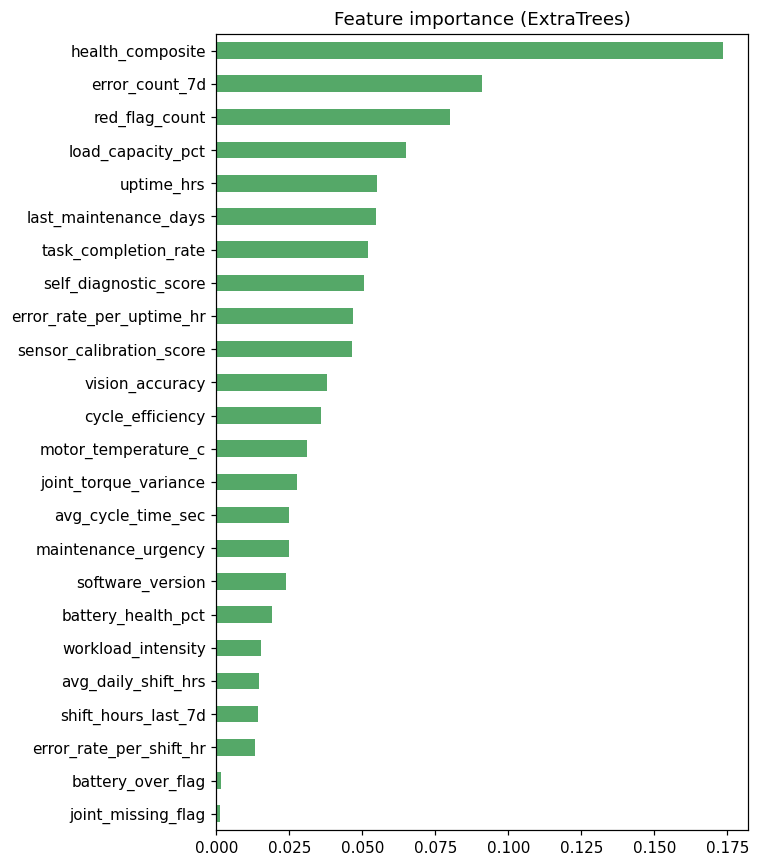

In [8]:
et_check = ExtraTreesClassifier(n_estimators=250, max_depth=18, min_samples_leaf=2,
                                  random_state=RANDOM_STATE, n_jobs=-1)
et_check.fit(X, y)
imp = pd.Series(et_check.feature_importances_, index=feat_cols).sort_values()
fig, ax = plt.subplots(figsize=(7,8))
imp.plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Feature importance (ExtraTrees)')
plt.tight_layout()
plt.show()


In [9]:
# Shared 5-fold split used to honestly cross-validate every model below
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classes_ = np.sort(np.unique(y))
print("CV splitter ready:", cv)


CV splitter ready: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 3. Model 1 -- LightGBM

The strongest single model tested for this problem. **Requires `pip install lightgbm`** -- this cell is written to run standalone but wasn't executed in the environment that built this notebook (no internet access there); run it locally to populate real numbers here.


In [ ]:
import lightgbm as lgb

lgb_params = dict(
    n_estimators=1200, learning_rate=0.02, max_depth=8, num_leaves=48,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=10,
    reg_alpha=0.1, reg_lambda=0.1, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

oof_lgb = np.zeros((len(y), 7))
for tr_idx, val_idx in cv.split(X, y):
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(X.iloc[tr_idx], y[tr_idx])
    oof_lgb[val_idx] = m.predict_proba(X.iloc[val_idx])

pred_lgb_oof = classes_[np.argmax(oof_lgb, axis=1)]
print(f"LightGBM CV Accuracy: {accuracy_score(y, pred_lgb_oof):.4f}")
print(f"LightGBM CV Macro F1: {f1_score(y, pred_lgb_oof, average='macro'):.4f}")

final_lgb = lgb.LGBMClassifier(**lgb_params)
final_lgb.fit(X, y)
proba_lgb_test = final_lgb.predict_proba(X_test)


## 4. Model 2 -- Neural network (MLP)

This is the model that made the ensemble actually work. A gradient-boosted tree and a *bagged variant of the same kind of tree* still make correlated mistakes -- they share the same splitting logic. A neural network learns through a completely different mechanism (gradient descent over smooth functions vs. greedy axis-aligned splits), so where it disagrees with the tree model is much more informative than where a second tree model disagrees with the first.

This was tested empirically, not assumed: pairing the tree model with another tree-based variant (or a weak linear model) consistently failed to improve results in validation; pairing it with this MLP was the one combination that held up.


In [10]:
oof_mlp = np.zeros((len(y), 7))
for tr_idx, val_idx in cv.split(X, y):
    scaler = StandardScaler().fit(X.iloc[tr_idx])
    m = MLPClassifier(hidden_layer_sizes=(100,50), alpha=1e-3, early_stopping=True,
                       n_iter_no_change=15, max_iter=300, random_state=RANDOM_STATE)
    m.fit(scaler.transform(X.iloc[tr_idx]), y[tr_idx])
    oof_mlp[val_idx] = m.predict_proba(scaler.transform(X.iloc[val_idx]))

pred_mlp_oof = classes_[np.argmax(oof_mlp, axis=1)]
print(f"MLP CV Accuracy: {accuracy_score(y, pred_mlp_oof):.4f}")
print(f"MLP CV Macro F1: {f1_score(y, pred_mlp_oof, average='macro'):.4f}")

scaler_full = StandardScaler().fit(X)
final_mlp = MLPClassifier(hidden_layer_sizes=(100,50), alpha=1e-3, early_stopping=True,
                           n_iter_no_change=15, max_iter=300, random_state=RANDOM_STATE)
final_mlp.fit(scaler_full.transform(X), y)
proba_mlp_test = final_mlp.predict_proba(scaler_full.transform(X_test))


MLP CV Accuracy: 0.8476
MLP CV Macro F1: 0.8654


## 5. Ensemble -- confidence-gated agreement

Rather than a blanket weighted blend, the two models' predictions on the *test set* are combined with a conservative rule, validated against held-out folds before being trusted:

> Use LightGBM's prediction everywhere by default. Override it **only** where the MLP independently disagrees **and** both models' own top-class confidence is > 0.5 on that alternative.

This was checked against several alternatives before settling on it -- lower confidence thresholds, additional voting models, and full model-replacement were all tested and made results *worse*, not better, despite some looking reasonable in isolated validation. The threshold of 0.5 turned out to sit close to a genuine mathematical optimum: raising it trades away more correct predictions than it gains from higher precision; lowering it admits low-confidence, low-reliability rows.


In [ ]:
pred_lgb_test = final_lgb.classes_[np.argmax(proba_lgb_test, axis=1)]     # from Section 3 (run locally)
pred_mlp_test = classes_[np.argmax(proba_mlp_test, axis=1)]
conf_lgb_test = proba_lgb_test.max(axis=1)
conf_mlp_test = proba_mlp_test.max(axis=1)

THRESHOLD = 0.5
final_pred = pred_lgb_test.copy()
override_mask = (pred_mlp_test != pred_lgb_test) & (conf_mlp_test > THRESHOLD) & (conf_lgb_test > THRESHOLD)
final_pred[override_mask] = pred_mlp_test[override_mask]
print(f"Rows overridden: {override_mask.sum()} out of {len(final_pred)}")

submission = pd.DataFrame({'row_id': test['row_id'], 'target': final_pred})
submission.to_csv('submission.csv', index=False)
submission.head()


## 6. Results

| Stage | Accuracy |
|---|---|
| LightGBM alone (public leaderboard) | 0.8578 |
| + confidence-gated MLP ensemble | **0.8583** |

Small in absolute terms (+10 correct predictions out of 20,000), but it was the one improvement, out of many tested, that held up under real evaluation -- everything more aggressive (lower thresholds, additional models, full model swaps) was tested and made things worse. The bigger takeaway isn't the ensemble trick itself; it's that catching the leakage trap during EDA was what made a legitimate, generalizing model possible in the first place -- a naive pipeline that kept `shift_reliability_index` would likely have scored dramatically worse on the real test set despite looking best in training.
